<a href="https://colab.research.google.com/github/LiaIssakov/Portfolio_2025/blob/main/knn_with_kd_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# kNN and k-d trees

(Notebook with improvements by Eileen An, Fall 2023)

Given a dataset with $n$ points in $\mathbb{R}^d$, we want to find the $k$ nearest neighbours (**kNN**) for each of many  query points.

We'd like to do it faster than by going through all the input points for each query point. It is possible!

We will play with a data structure called k-d trees (k-dimensional trees) and try to answer some questions:
- Are k-d trees really faster than a brute-force approach (see below)?
  - Let's start with $d=2$. How much faster is it?

We will also discuss:
- **Important**: How does the speed depend on the dimension?
- **Why** do you think the dimension plays a role?

> BTW: Why is k always in the name?! Here k was meant to denote the dimension of the space, but noone uses it like that.

# Main Task:
**Determine the largest dimension for which k-d trees are still worth using.**

> k-d trees are worth using if using them is faster than using the brute force method.

New in 2024/25: Vector databases https://en.wikipedia.org/wiki/Vector_database are gaining popularity, mostly due to applications of nearest-neighbour search in AI. From this perspective a kd-tree would be one potential implementation of an *index* in such a database.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KDTree # NEW

# Brute force approach
The following two functions use a brute force method by calculating the Euclidean distances between each element.

In [ ]:
def closest_indices(X, q, k):
    '''
    Returns the indices of the k closest elements in X
    (by Euclidean distance) to the query vector v.

    Args:
    X: a 2D np.array of shape (n,d)
    v: an np.array of shape (d)
    k: int value for number of indices to return

    Returns:
    An np.array of k indices
    '''
    # can we be smarter here?
    return np.linalg.norm(X - q, axis=1).argsort()[:k]

# similar to the function above but for multiple query points, Q
def closest_indices_many(X, Q, k):
    '''
    Runs closest_indices for each query q in Q.
    Q is an np.array of query vectors.

    Returns:
    A 2-dimensional np.array containing k indices for each query
    '''
    return np.array([closest_indices(X, q, k) for q in Q])

The example below finds the 2 closest indices in the array [[1], [2], [3]] to each of the following elements in [[0.1], [2.2], [3.3], [0.6]] and returns it in an np.array.

In [ ]:
X = np.array([[-1.0], [2.5], [3.0]])
Q = [[0.0], [2.2]]
inds = closest_indices_many(X, Q, 2)
print("indices:", inds)

In [ ]:
for q, res in zip(Q, inds):
    print(f"for {q=} nearest points were:\n {X[res]}\n") #

# Does it make sense for MNIST?

In [ ]:
from keras.datasets import mnist

(x_train,_), (x_test, _) = mnist.load_data()

In [ ]:
query_vector = x_test[54].reshape(28*28)

In [ ]:
nbr_inds = closest_indices(query_vector, x_train.reshape(-1, 28*28), 10)

In [ ]:
plt.imshow(query_vector.reshape(28,28), cmap='gray')

In [ ]:
plt.imshow(np.concatenate(x_train[nbr_inds], axis=1), cmap='gray')

# Can we find nearet neighbours faster?

... in particular without looking at all the dataset for each query image/vector?

Yes, see below!

## Overview of the k-d tree data structure


> We'll discuss it in class in slightly more detail.

Here is a brief overview of how the algorithm works. The details are not super important, but it'd be good if you knew the outline.

> BTW: If you want to know the details, don't look at the Wikipedia page about k-d trees, whoever wrote it is rather confused (see wiki discussion page).

**Construction**: We cut the space along the x or y axis.

> This corresponds to decomposing the space into halfspaces determined by a splitting hyperplane. Here we use axis-aligned hyperplanes. (See picture!)

> In higher dimensions we just cycle through all available axes.

**Nearest neighbour query**: We follow the arrows deciding if we should go up/down or left/right. We're done when we locate the smallest box (region) in which the query point $q$ resides. We then retrace our steps and check if the visited points are better (closer to $q$).

> If that was it, it'd always be super fast!

We also need to decide if a closer point may reside on the other side of the splitting hyperplane. This is equivelent to checking if the ball centered at $q$ with a radius of $d$ sticks out to the other side; $d$ is the current estimation for the closest point to $q$.

> In the example below, we would have to check the adjacent box, because the ball I drew sticks out.

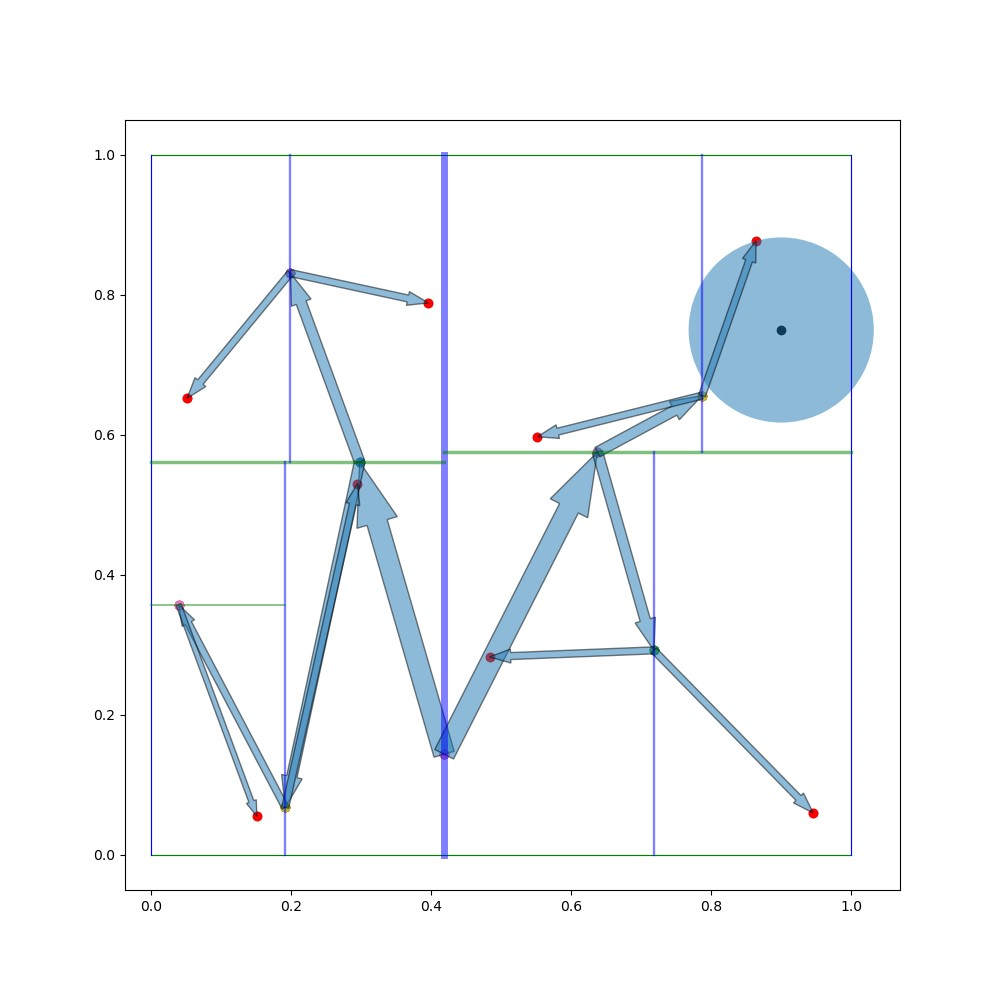

# Task 1: Comparing brute force and k-d tree on large amounts of data

> We'll use the brute force approach and KDTrees from sklearn and time both.

In [ ]:
# data
n, m, d, k_nearest = 10_000, 1_000, 2, 3
X = np.random.rand(n, d)  # data points
Q = np.random.rand(m, d)  # query points

Brute force approach:

In [ ]:
%%time
inds_slow = closest_indices_many(X, Q, k=k_nearest)

You can use the help function to display information about the query function for kd_tree.

In [ ]:
help(KDTree)

In [ ]:
help(KDTree.query)

In [ ]:
# note what it returns, check what "return_distance" parameter does!

k-d tree approach:

In [ ]:
%%time
# TODO: build the k-d tree data structure


In [ ]:
%%time
# TODO: perform the queries, store the indices in variable inds...
# tip: like with numpy, avoid a for loop!


In [ ]:
assert np.array_equal(inds, inds_slow)  # make sure the results are the same

# On mnist?

- How well does it work for, say, mnist data?

In [ ]:
from keras.datasets import mnist

(XM,_), (QM, _) = mnist.load_data()

In [ ]:
# build kd-tree on XM, remember that it works on vectors!

In [ ]:
# query with a small number from QM -- say we want to wait for roughly 10 seconds

In [ ]:
%%time


In [ ]:
# try it with the brute-force approach. Was it worth using kd-trees?

In [ ]:
%%time


# Bonus: ball queries
## You can also try to play with ball queries.

In [ ]:
# help(kd_tree.query_radius)

# Hard extra task:

Can you implement a basic k-d tree?

In [ ]:
# your code here